In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. LOAD PROCESSED DATASET

df = pd.read_csv("../data/processed/mhvi_processed.csv")

df.head()

,Region,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,Central,88.8,64.7,96.4,98.7,82.5,84.0,0.2,44.4,19.8,91.8,72.0,9.1
1,Greater Accra,87.3,60.7,94.3,94.2,91.3,92.3,0.2,38.8,10.0,98.5,91.4,2.4
2,Eastern,91.0,64.8,97.9,99.6,89.2,90.1,0.7,37.5,15.7,88.7,74.7,8.2
3,Ashanti,90.7,66.1,96.8,99.4,91.3,92.8,0.3,37.5,16.1,96.8,84.7,8.7
4,Upper West,95.0,71.7,98.9,98.6,92.8,91.7,0.0,46.3,43.4,97.9,26.9,52.0


In [3]:
# 3. DATA STRUCTURE OVERVIEW

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

Shape of dataset: (16, 13)

Columns:
 Index(['Region', 'ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Height_below_145cm', 'Any_anaemia', 'No_education', 'Improved_water',
       'Improved_sanitation', 'Lowest_wealth_quintile'],
      dtype='object')


In [4]:
# 4. MISSING VALUES CHECK

df.isnull().sum()

Region                       0
ANC_4plus_visits             0
ANC_first_before_4mo         0
ANC_BP_measured              0
ANC_urine_taken              0
Facility_delivery            0
Skilled_provider_delivery    0
Height_below_145cm           0
Any_anaemia                  0
No_education                 0
Improved_water               0
Improved_sanitation          0
Lowest_wealth_quintile       0
dtype: int64

In [5]:
# 5. SUMMARY STATISTICS

df.describe().T

,count,mean,std,min,25%,50%,75%,max
ANC_4plus_visits,16.0,87.65625,6.521142,73.9,84.950,89.75,91.650,95.8
ANC_first_before_4mo,16.0,64.78125,5.562160,50.2,63.350,65.60,67.175,71.7
ANC_BP_measured,16.0,96.75625,2.267148,92.0,94.900,97.15,98.650,99.4
ANC_urine_taken,16.0,97.05000,2.685517,91.6,95.700,98.30,98.825,99.6
Facility_delivery,16.0,85.23125,9.097085,66.8,82.575,88.55,91.300,97.7
Skilled_provider_delivery,16.0,86.56250,8.647688,69.5,83.850,89.75,92.425,98.3
Height_below_145cm,16.0,0.50625,0.306526,0.0,0.275,0.50,0.725,1.0
Any_anaemia,16.0,41.94375,5.665918,30.1,37.500,43.10,46.000,51.8
No_education,16.0,29.48125,15.043015,10.0,17.575,22.50,38.150,56.7
Improved_water,16.0,84.91250,12.999891,59.3,80.475,88.55,94.925,98.5


In [6]:
# 6. ANAEMIA BURDEN RANKING (EXPLORATORY)

df_sorted = df.sort_values(by="Any_anaemia", ascending=False)
df_sorted[["Region", "Any_anaemia"]]

,Region,Any_anaemia
9,Oti,51.8
13,Northern,48.4
5,Upper East,47.0
4,Upper West,46.3
6,Western,45.9
15,North East,45.0
0,Central,44.4
14,Savannah,43.2
8,Volta,43.0
12,Bono East,40.3


In [7]:
# 7. MULTI-INDICATOR REGIONAL SNAPSHOT

df.set_index("Region")[[
    "Any_anaemia",
    "No_education",
    "Lowest_wealth_quintile",
    "Facility_delivery",
    "Skilled_provider_delivery"
]].sort_values(by="Any_anaemia", ascending=False)

,Any_anaemia,No_education,Lowest_wealth_quintile,Facility_delivery,Skilled_provider_delivery
Region,,,,,
Oti,51.8,35.1,30.2,66.8,69.5
Northern,48.4,51.2,43.6,69.0,70.9
Upper East,47.0,36.4,57.0,97.7,98.3
Upper West,46.3,43.4,52.0,92.8,91.7
Western,45.9,17.7,9.0,84.1,85.4
North East,45.0,53.8,64.1,82.6,83.4
Central,44.4,19.8,9.1,82.5,84.0
Savannah,43.2,56.7,55.2,71.0,73.1
Volta,43.0,17.2,13.9,90.5,93.8


In [8]:
# 8. FULL REGIONAL PROFILE (ALL KEY INDICATORS)

profile_cols = [
    "ANC_4plus_visits",
    "ANC_first_before_4mo",
    "ANC_BP_measured",
    "ANC_urine_taken",
    "Facility_delivery",
    "Skilled_provider_delivery",
    "Any_anaemia",
    "No_education",
    "Lowest_wealth_quintile",
    "Improved_water",
    "Improved_sanitation",
    "Height_below_145cm"
]

df.set_index("Region")[profile_cols].sort_values(
    by="Any_anaemia",
    ascending=False
)

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Lowest_wealth_quintile,Improved_water,Improved_sanitation,Height_below_145cm
Region,,,,,,,,,,,,
Oti,77.1,64.1,97.4,97.5,66.8,69.5,51.8,35.1,30.2,66.9,48.7,0.2
Northern,81.2,50.2,92.0,91.8,69.0,70.9,48.4,51.2,43.6,72.0,29.9,0.6
Upper East,95.8,71.5,98.8,97.2,97.7,98.3,47.0,36.4,57.0,96.8,30.0,1.0
Upper West,95.0,71.7,98.9,98.6,92.8,91.7,46.3,43.4,52.0,97.9,26.9,0.0
Western,91.6,68.6,95.0,96.2,84.1,85.4,45.9,17.7,9.0,94.3,72.6,0.5
North East,79.8,61.1,94.6,91.6,82.6,83.4,45.0,53.8,64.1,59.3,21.9,0.3
Central,88.8,64.7,96.4,98.7,82.5,84.0,44.4,19.8,9.1,91.8,72.0,0.2
Savannah,73.9,57.0,93.5,94.1,71.0,73.1,43.2,56.7,55.2,61.9,26.5,0.8
Volta,94.2,71.2,99.4,99.4,90.5,93.8,43.0,17.2,13.9,88.4,67.7,1.0


In [9]:
# Separate Region from indicators

regions = df["Region"]

data = df.drop(columns=["Region"])

data.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,88.8,64.7,96.4,98.7,82.5,84.0,0.2,44.4,19.8,91.8,72.0,9.1
1,87.3,60.7,94.3,94.2,91.3,92.3,0.2,38.8,10.0,98.5,91.4,2.4
2,91.0,64.8,97.9,99.6,89.2,90.1,0.7,37.5,15.7,88.7,74.7,8.2
3,90.7,66.1,96.8,99.4,91.3,92.8,0.3,37.5,16.1,96.8,84.7,8.7
4,95.0,71.7,98.9,98.6,92.8,91.7,0.0,46.3,43.4,97.9,26.9,52.0


In [10]:
# Correlation matrix

corr_matrix = data.corr()

corr_matrix

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
ANC_4plus_visits,1.000000,0.752575,0.645092,0.622351,0.869339,0.870317,0.083859,-0.321818,-0.590944,0.881133,0.386899,-0.339499
ANC_first_before_4mo,0.752575,1.000000,0.843425,0.745272,0.700428,0.707527,0.074367,-0.136289,-0.450360,0.621295,0.221164,-0.182023
ANC_BP_measured,0.645092,0.843425,1.000000,0.853363,0.596257,0.607017,0.095392,-0.269404,-0.368889,0.464020,0.165071,-0.096943
ANC_urine_taken,0.622351,0.745272,0.853363,1.000000,0.494180,0.516029,0.064384,-0.394390,-0.614243,0.593578,0.475332,-0.467745
Facility_delivery,0.869339,0.700428,0.596257,0.494180,1.000000,0.995269,0.098186,-0.519785,-0.537080,0.764339,0.333776,-0.209505
Skilled_provider_delivery,0.870317,0.707527,0.607017,0.516029,0.995269,1.000000,0.150241,-0.536241,-0.578889,0.761714,0.376091,-0.255420
Height_below_145cm,0.083859,0.074367,0.095392,0.064384,0.098186,0.150241,1.000000,-0.118396,-0.000840,-0.078318,-0.134228,0.066305
Any_anaemia,-0.321818,-0.136289,-0.269404,-0.394390,-0.519785,-0.536241,-0.118396,1.000000,0.528854,-0.340345,-0.517578,0.434559
No_education,-0.590944,-0.450360,-0.368889,-0.614243,-0.537080,-0.578889,-0.000840,0.528854,1.000000,-0.715307,-0.929082,0.910688
Improved_water,0.881133,0.621295,0.464020,0.593578,0.764339,0.761714,-0.078318,-0.340345,-0.715307,1.000000,0.604011,-0.554063


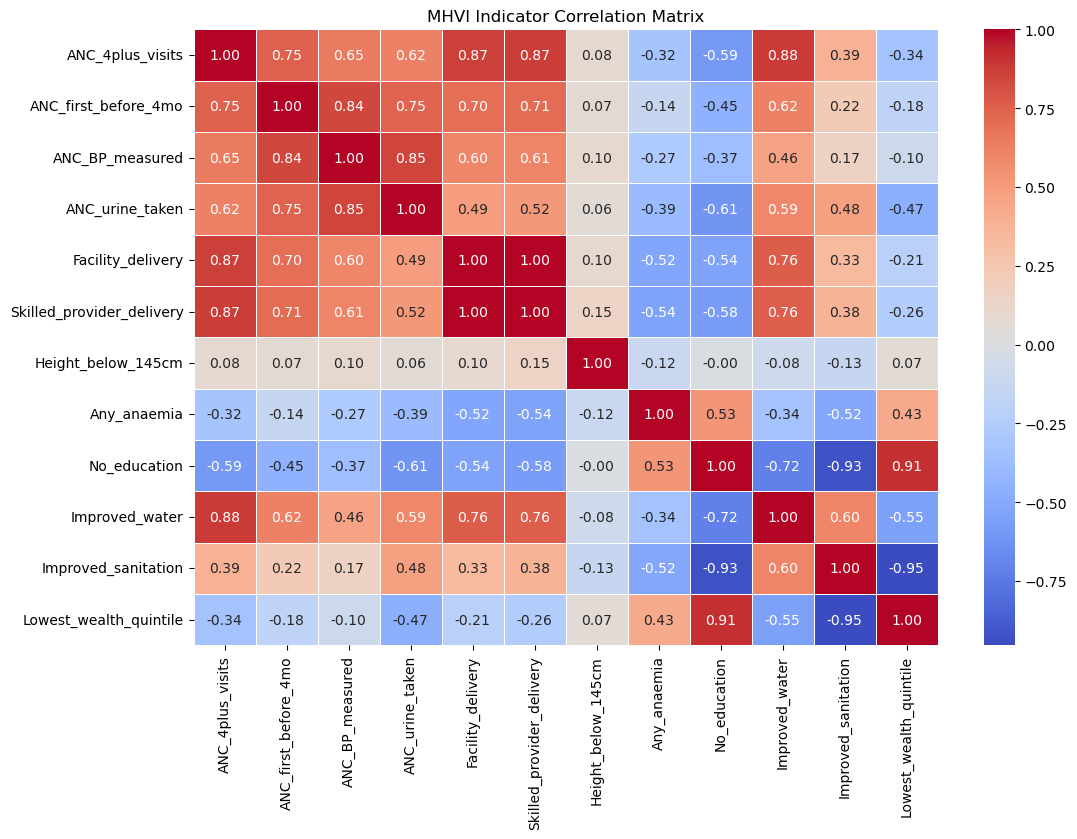

In [11]:
# Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("MHVI Indicator Correlation Matrix")
plt.show()

In [12]:
# Identify highly correlated pairs

threshold = 0.80

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    round(corr_value, 2)
                )
            )

high_corr_pairs

[('ANC_BP_measured', 'ANC_first_before_4mo', np.float64(0.84)),
 ('ANC_urine_taken', 'ANC_BP_measured', np.float64(0.85)),
 ('Facility_delivery', 'ANC_4plus_visits', np.float64(0.87)),
 ('Skilled_provider_delivery', 'ANC_4plus_visits', np.float64(0.87)),
 ('Skilled_provider_delivery', 'Facility_delivery', np.float64(1.0)),
 ('Improved_water', 'ANC_4plus_visits', np.float64(0.88)),
 ('Improved_sanitation', 'No_education', np.float64(-0.93)),
 ('Lowest_wealth_quintile', 'No_education', np.float64(0.91)),
 ('Lowest_wealth_quintile', 'Improved_sanitation', np.float64(-0.95))]

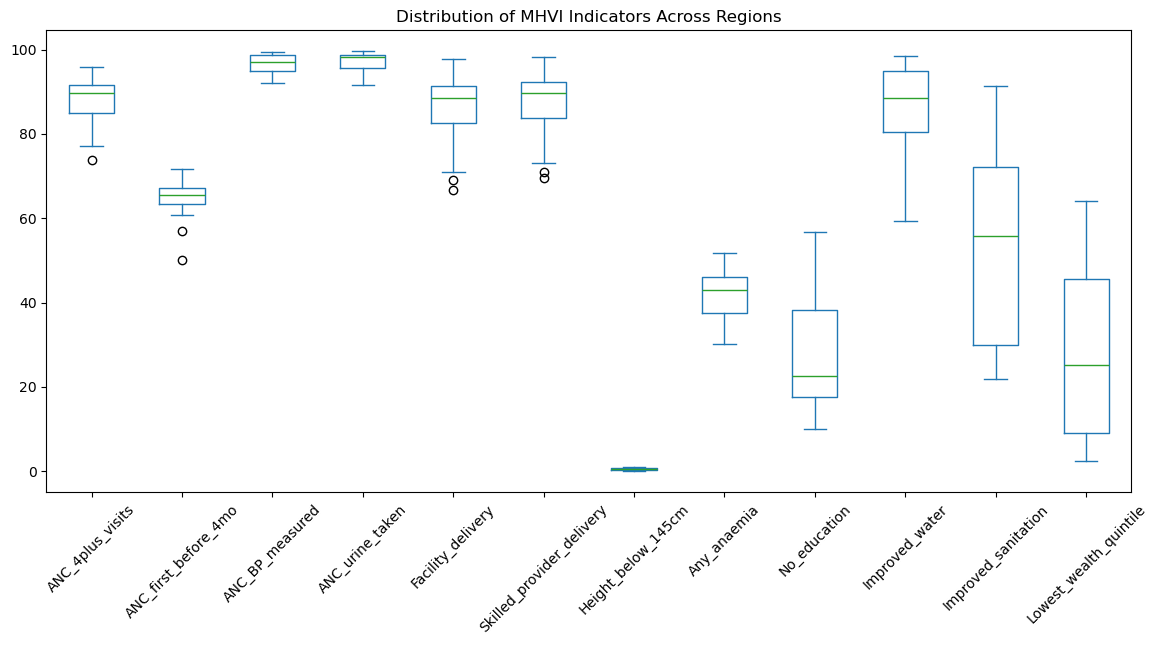

In [13]:
# Boxplots for all indicators

import matplotlib.pyplot as plt

data.plot(
    kind='box',
    figsize=(14,6),
    rot=45
)

plt.title("Distribution of MHVI Indicators Across Regions")
plt.show()

In [14]:
# Standard deviation of indicators

data.std().sort_values()

Height_below_145cm            0.306526
ANC_BP_measured               2.267148
ANC_urine_taken               2.685517
ANC_first_before_4mo          5.562160
Any_anaemia                   5.665918
ANC_4plus_visits              6.521142
Skilled_provider_delivery     8.647688
Facility_delivery             9.097085
Improved_water               12.999891
No_education                 15.043015
Lowest_wealth_quintile       20.744830
Improved_sanitation          22.552601
dtype: float64

In [15]:
# Remove low-variance indicator

mhvi_data = data.drop(columns=["Height_below_145cm"])

print("Shape:", mhvi_data.shape)

mhvi_data.head()

Shape: (16, 11)


,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,88.8,64.7,96.4,98.7,82.5,84.0,44.4,19.8,91.8,72.0,9.1
1,87.3,60.7,94.3,94.2,91.3,92.3,38.8,10.0,98.5,91.4,2.4
2,91.0,64.8,97.9,99.6,89.2,90.1,37.5,15.7,88.7,74.7,8.2
3,90.7,66.1,96.8,99.4,91.3,92.8,37.5,16.1,96.8,84.7,8.7
4,95.0,71.7,98.9,98.6,92.8,91.7,46.3,43.4,97.9,26.9,52.0


In [16]:
# Step 6.1: Create copy for direction alignment

mhvi_aligned = mhvi_data.copy()

print("Alignment dataset shape:", mhvi_aligned.shape)
mhvi_aligned.head()

Alignment dataset shape: (16, 11)


,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,88.8,64.7,96.4,98.7,82.5,84.0,44.4,19.8,91.8,72.0,9.1
1,87.3,60.7,94.3,94.2,91.3,92.3,38.8,10.0,98.5,91.4,2.4
2,91.0,64.8,97.9,99.6,89.2,90.1,37.5,15.7,88.7,74.7,8.2
3,90.7,66.1,96.8,99.4,91.3,92.8,37.5,16.1,96.8,84.7,8.7
4,95.0,71.7,98.9,98.6,92.8,91.7,46.3,43.4,97.9,26.9,52.0


In [17]:
# Step 6.1b: Reverse protective indicators
# Higher value = higher vulnerability

protective_vars = [
    'ANC_4plus_visits',
    'ANC_first_before_4mo',
    'ANC_BP_measured',
    'ANC_urine_taken',
    'Facility_delivery',
    'Skilled_provider_delivery',
    'Improved_water',
    'Improved_sanitation'
]

for col in protective_vars:
    mhvi_aligned[col] = 100 - mhvi_aligned[col]

print("Direction alignment completed")
mhvi_aligned.head()

Direction alignment completed


,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,11.2,35.3,3.6,1.3,17.5,16.0,44.4,19.8,8.2,28.0,9.1
1,12.7,39.3,5.7,5.8,8.7,7.7,38.8,10.0,1.5,8.6,2.4
2,9.0,35.2,2.1,0.4,10.8,9.9,37.5,15.7,11.3,25.3,8.2
3,9.3,33.9,3.2,0.6,8.7,7.2,37.5,16.1,3.2,15.3,8.7
4,5.0,28.3,1.1,1.4,7.2,8.3,46.3,43.4,2.1,73.1,52.0


In [18]:
# Check before vs after alignment

check_col = 'ANC_4plus_visits'

comparison = pd.DataFrame({
    "Original": mhvi_data[check_col],
    "Aligned": mhvi_aligned[check_col]
})

comparison.head()

,Original,Aligned
0,88.8,11.2
1,87.3,12.7
2,91.0,9.0
3,90.7,9.3
4,95.0,5.0


In [19]:
# Step 6.2: Min-Max Normalization

mhvi_normalized = (
    mhvi_aligned - mhvi_aligned.min()
) / (
    mhvi_aligned.max() - mhvi_aligned.min()
)

print("Normalized dataset shape:", mhvi_normalized.shape)
mhvi_normalized.head()

Normalized dataset shape: (16, 11)


,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,0.319635,0.325581,0.405405,0.1125,0.491909,0.496528,0.658986,0.209850,0.170918,0.279137,0.108590
1,0.388128,0.511628,0.689189,0.6750,0.207120,0.208333,0.400922,0.000000,0.000000,0.000000,0.000000
2,0.219178,0.320930,0.202703,0.0000,0.275081,0.284722,0.341014,0.122056,0.250000,0.240288,0.094003
3,0.232877,0.260465,0.351351,0.0250,0.207120,0.190972,0.341014,0.130621,0.043367,0.096403,0.102107
4,0.036530,0.000000,0.067568,0.1250,0.158576,0.229167,0.746544,0.715203,0.015306,0.928058,0.803890


In [20]:
# Check range (must be 0–1)

mhvi_normalized.describe().loc[['min', 'max']]

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [21]:
# Step 7.1: Construct MHVI (Equal Weights)

mhvi_normalized["MHVI"] = mhvi_normalized.mean(axis=1)

print("MHVI created successfully")
mhvi_normalized[["MHVI"]].head()

MHVI created successfully


,MHVI
0,0.325367
1,0.280029
2,0.213634
3,0.180118
4,0.347804


In [22]:
# MHVI summary statistics

mhvi_normalized["MHVI"].describe()

count    16.000000
mean      0.403781
std       0.236012
min       0.180118
25%       0.263430
50%       0.325065
75%       0.426922
max       0.861460
Name: MHVI, dtype: float64

In [23]:
# Step 8.1: Rank regions by MHVI

mhvi_results = mhvi_normalized.copy()

# Add MHVI column (just in case)
mhvi_results["MHVI"] = mhvi_results["MHVI"]

# Sort by vulnerability (highest first)
mhvi_ranked = mhvi_results.sort_values(by="MHVI", ascending=False)

mhvi_ranked[["MHVI"]].head(10)

,MHVI
13,0.861460
14,0.839502
15,0.772985
9,0.649881
12,0.352602
4,0.347804
6,0.329201
0,0.325367
7,0.324763
5,0.322386


In [24]:
# Step 8.2: Full ranked table

mhvi_ranked["Rank"] = range(1, len(mhvi_ranked) + 1)

mhvi_ranked[["Rank", "MHVI"]]

,Rank,MHVI
13,1,0.861460
14,2,0.839502
15,3,0.772985
9,4,0.649881
12,5,0.352602
4,6,0.347804
6,7,0.329201
0,8,0.325367
7,9,0.324763
5,10,0.322386


In [25]:
# Step 8.3: Key insights

most_vulnerable = mhvi_ranked.index[0]
least_vulnerable = mhvi_ranked.index[-1]

print("Most vulnerable region:", most_vulnerable)
print("Least vulnerable region:", least_vulnerable)

Most vulnerable region: 13
Least vulnerable region: 3


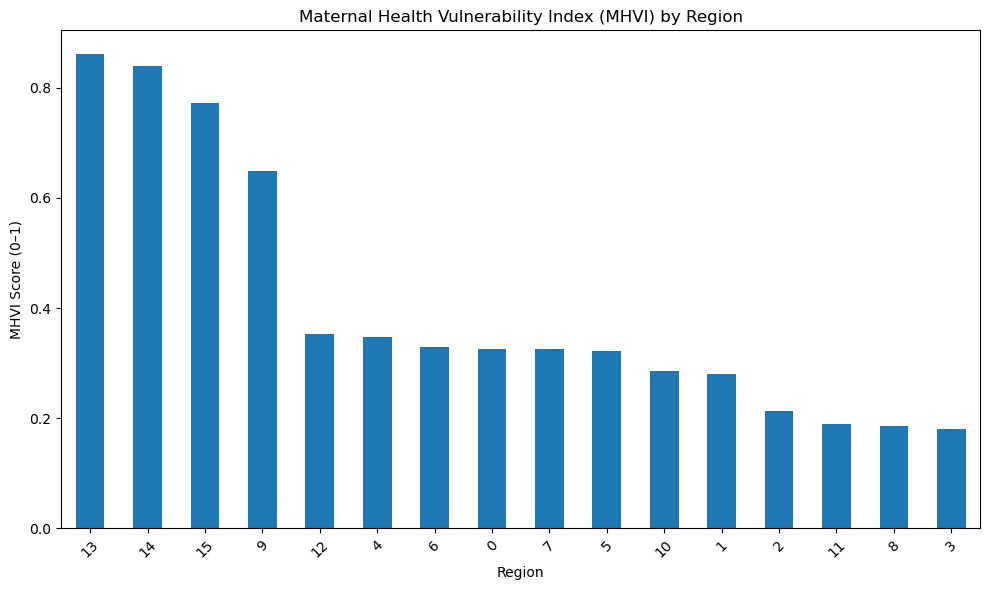

In [26]:
# Step 8.4: MHVI visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
mhvi_ranked["MHVI"].plot(kind="bar")
plt.title("Maternal Health Vulnerability Index (MHVI) by Region")
plt.ylabel("MHVI Score (0–1)")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Step 9.1: Correlation validation

validation_cols = [
    "Lowest_wealth_quintile",
    "No_education",
    "Any_anaemia"
]

# We use aligned dataset (before normalization)
validation_data = mhvi_aligned.copy()
validation_data["MHVI"] = mhvi_normalized["MHVI"]

correlations = validation_data[validation_cols + ["MHVI"]].corr()["MHVI"].sort_values(ascending=False)

print(correlations)

MHVI                      1.000000
No_education              0.866183
Lowest_wealth_quintile    0.658630
Any_anaemia               0.584887
Name: MHVI, dtype: float64


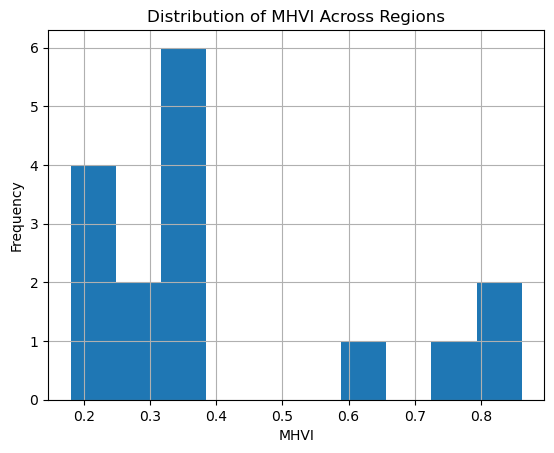

In [28]:
# Step 9.2: Distribution check

mhvi_normalized["MHVI"].hist(bins=10)
plt.title("Distribution of MHVI Across Regions")
plt.xlabel("MHVI")
plt.ylabel("Frequency")
plt.show()

In [29]:
# Step 9.3: Spread check

mhvi_normalized["MHVI"].describe()

count    16.000000
mean      0.403781
std       0.236012
min       0.180118
25%       0.263430
50%       0.325065
75%       0.426922
max       0.861460
Name: MHVI, dtype: float64

In [30]:
# Step 10.1: Final results table

final_results = mhvi_normalized.copy()

# Add MHVI if not already clean
final_results["MHVI"] = mhvi_normalized["MHVI"]

# Rank regions
final_results = final_results.sort_values(by="MHVI", ascending=False)
final_results["Rank"] = range(1, len(final_results) + 1)

final_results[["Rank", "MHVI"]].head()

,Rank,MHVI
13,1,0.861460
14,2,0.839502
15,3,0.772985
9,4,0.649881
12,5,0.352602


In [31]:
# Step 10.2: Vulnerability classification

q1 = final_results["MHVI"].quantile(0.33)
q2 = final_results["MHVI"].quantile(0.66)

def classify_mhvi(x):
    if x <= q1:
        return "Low Vulnerability"
    elif x <= q2:
        return "Medium Vulnerability"
    else:
        return "High Vulnerability"

final_results["Vulnerability_Level"] = final_results["MHVI"].apply(classify_mhvi)

final_results[["MHVI", "Vulnerability_Level"]].head()

,MHVI,Vulnerability_Level
13,0.861460,High Vulnerability
14,0.839502,High Vulnerability
15,0.772985,High Vulnerability
9,0.649881,High Vulnerability
12,0.352602,High Vulnerability


In [32]:
# Step 10.3: Category summary

final_results.groupby("Vulnerability_Level")["MHVI"].describe()

,count,mean,std,min,25%,50%,75%,max
Vulnerability_Level,,,,,,,,
High Vulnerability,6.0,0.637372,0.234334,0.347804,0.426922,0.711433,0.822873,0.861460
Low Vulnerability,5.0,0.209747,0.041321,0.180118,0.185842,0.189110,0.213634,0.280029
Medium Vulnerability,5.0,0.317505,0.017887,0.285810,0.322386,0.324763,0.325367,0.329201


In [33]:
# Step 10.4: Category counts

final_results["Vulnerability_Level"].value_counts()

Vulnerability_Level
High Vulnerability      6
Medium Vulnerability    5
Low Vulnerability       5
Name: count, dtype: int64

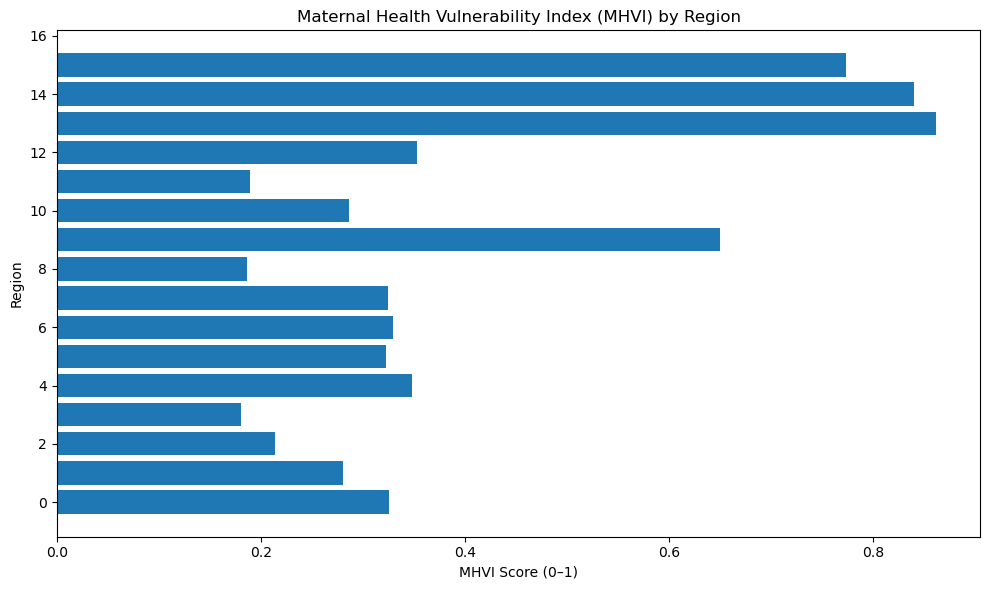

In [34]:
# Step 11.1: Final MHVI ranking plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

final_results_sorted = final_results.sort_values("MHVI", ascending=True)

plt.barh(final_results_sorted.index, final_results_sorted["MHVI"])

plt.title("Maternal Health Vulnerability Index (MHVI) by Region")
plt.xlabel("MHVI Score (0–1)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

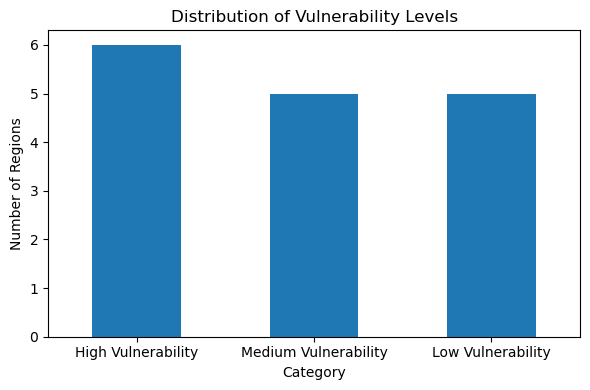

In [35]:
# Step 11.2: Category distribution

category_counts = final_results["Vulnerability_Level"].value_counts()

plt.figure(figsize=(6,4))
category_counts.plot(kind="bar")

plt.title("Distribution of Vulnerability Levels")
plt.xlabel("Category")
plt.ylabel("Number of Regions")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# Step 11.3: Final export table

export_table = final_results[["Rank", "MHVI", "Vulnerability_Level"]]

export_table

,Rank,MHVI,Vulnerability_Level
13,1,0.861460,High Vulnerability
14,2,0.839502,High Vulnerability
15,3,0.772985,High Vulnerability
9,4,0.649881,High Vulnerability
12,5,0.352602,High Vulnerability
4,6,0.347804,High Vulnerability
6,7,0.329201,Medium Vulnerability
0,8,0.325367,Medium Vulnerability
7,9,0.324763,Medium Vulnerability
5,10,0.322386,Medium Vulnerability


In [37]:
!pip install geopandas

In [38]:
import geopandas as gpd
print("Geopandas installed successfully")

Geopandas installed successfully


In [39]:
import pandas as pd

ghana_regions = pd.DataFrame({
    "NAME_1": [
        "western", "western north", "central", "greater accra",
        "volta", "oti", "eastern", "ashanti",
        "ahafo", "bono", "bono east", "northern",
        "savannah", "north east", "upper east", "upper west"
    ]
})

ghana_regions

,NAME_1
0,western
1,western north
2,central
3,greater accra
4,volta
5,oti
6,eastern
7,ashanti
8,ahafo
9,bono


In [40]:
mhvi_map_data = final_results.reset_index()

mhvi_map_data = mhvi_map_data.rename(columns={"index": "NAME_1"})

#  FORCE SAFE STRING CONVERSION 
mhvi_map_data["NAME_1"] = mhvi_map_data["NAME_1"].astype(str)

#  apply string methods
mhvi_map_data["NAME_1"] = mhvi_map_data["NAME_1"].str.strip().str.lower()

mhvi_map_data[["NAME_1", "MHVI"]].head()

,NAME_1,MHVI
0,13,0.861460
1,14,0.839502
2,15,0.772985
3,9,0.649881
4,12,0.352602


In [41]:
ghana_regions = pd.DataFrame({
    "NAME_1": [
        "western", "western north", "central", "greater accra",
        "volta", "oti", "eastern", "ashanti",
        "ahafo", "bono", "bono east", "northern",
        "savannah", "north east", "upper east", "upper west"
    ]
})

ghana_regions

,NAME_1
0,western
1,western north
2,central
3,greater accra
4,volta
5,oti
6,eastern
7,ashanti
8,ahafo
9,bono


In [42]:
ghana_mhvi = ghana_regions.merge(mhvi_map_data, on="NAME_1", how="left")

ghana_mhvi

,NAME_1,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI,Rank,Vulnerability_Level
0,western,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,western north,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,greater accra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,volta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,oti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,eastern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ashanti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ahafo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bono,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
ghana_mhvi[ghana_mhvi["MHVI"].isna()]

,NAME_1,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI,Rank,Vulnerability_Level
0,western,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,western north,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,greater accra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,volta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,oti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,eastern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ashanti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ahafo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bono,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


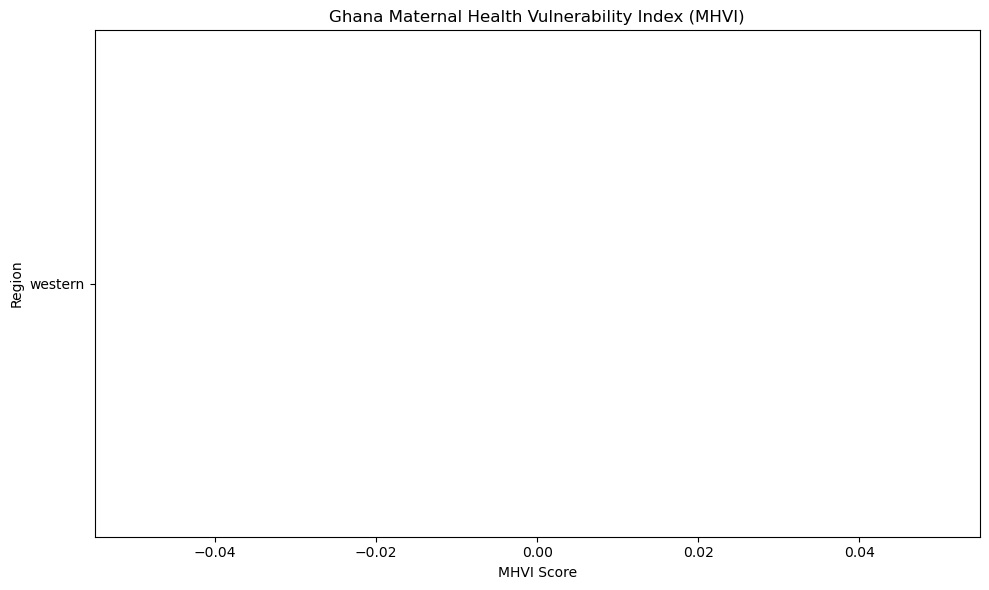

In [44]:
import matplotlib.pyplot as plt

ghana_mhvi_sorted = ghana_mhvi.sort_values("MHVI")

plt.figure(figsize=(10,6))
plt.barh(ghana_mhvi_sorted["NAME_1"], ghana_mhvi_sorted["MHVI"])

plt.title("Ghana Maternal Health Vulnerability Index (MHVI)")
plt.xlabel("MHVI Score")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [45]:
print("MHVI DATA REGIONS:")
print(mhvi_map_data["NAME_1"].unique())

print("\nGHANA REFERENCE REGIONS:")
print(ghana_regions["NAME_1"].unique())

MHVI DATA REGIONS:
['13' '14' '15' '9' '12' '4' '6' '0' '7' '5' '10' '1' '2' '11' '8' '3']

GHANA REFERENCE REGIONS:
['western' 'western north' 'central' 'greater accra' 'volta' 'oti'
 'eastern' 'ashanti' 'ahafo' 'bono' 'bono east' 'northern' 'savannah'
 'north east' 'upper east' 'upper west']


In [46]:
mhvi_map_data.head()

,NAME_1,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI,Rank,Vulnerability_Level
0,13,0.666667,1.000000,1.000000,0.9750,0.928803,0.951389,0.843318,0.882227,0.676020,0.884892,0.667747,0.861460,1,High Vulnerability
1,14,1.000000,0.683721,0.797297,0.6875,0.864078,0.875000,0.603687,1.000000,0.933673,0.933813,0.855754,0.839502,2,High Vulnerability
2,15,0.730594,0.493023,0.648649,1.0000,0.488673,0.517361,0.686636,0.937901,1.000000,1.000000,1.000000,0.772985,3,High Vulnerability
3,9,0.853881,0.353488,0.270270,0.2625,1.000000,1.000000,1.000000,0.537473,0.806122,0.614388,0.450567,0.649881,4,High Vulnerability
4,12,0.410959,0.232558,0.000000,0.0500,0.436893,0.454861,0.470046,0.486081,0.308673,0.492086,0.536467,0.352602,5,High Vulnerability


In [47]:
mhvi_map_data.columns

Index(['NAME_1', 'ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Any_anaemia', 'No_education', 'Improved_water', 'Improved_sanitation',
       'Lowest_wealth_quintile', 'MHVI', 'Rank', 'Vulnerability_Level'],
      dtype='object')

In [48]:
mhvi_map_data.index

RangeIndex(start=0, stop=16, step=1)

In [49]:
final_results.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI,Rank,Vulnerability_Level
13,0.666667,1.000000,1.000000,0.9750,0.928803,0.951389,0.843318,0.882227,0.676020,0.884892,0.667747,0.861460,1,High Vulnerability
14,1.000000,0.683721,0.797297,0.6875,0.864078,0.875000,0.603687,1.000000,0.933673,0.933813,0.855754,0.839502,2,High Vulnerability
15,0.730594,0.493023,0.648649,1.0000,0.488673,0.517361,0.686636,0.937901,1.000000,1.000000,1.000000,0.772985,3,High Vulnerability
9,0.853881,0.353488,0.270270,0.2625,1.000000,1.000000,1.000000,0.537473,0.806122,0.614388,0.450567,0.649881,4,High Vulnerability
12,0.410959,0.232558,0.000000,0.0500,0.436893,0.454861,0.470046,0.486081,0.308673,0.492086,0.536467,0.352602,5,High Vulnerability


In [50]:
final_results.columns

Index(['ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Any_anaemia', 'No_education', 'Improved_water', 'Improved_sanitation',
       'Lowest_wealth_quintile', 'MHVI', 'Rank', 'Vulnerability_Level'],
      dtype='object')

In [51]:
final_results.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI,Rank,Vulnerability_Level
13,0.666667,1.000000,1.000000,0.9750,0.928803,0.951389,0.843318,0.882227,0.676020,0.884892,0.667747,0.861460,1,High Vulnerability
14,1.000000,0.683721,0.797297,0.6875,0.864078,0.875000,0.603687,1.000000,0.933673,0.933813,0.855754,0.839502,2,High Vulnerability
15,0.730594,0.493023,0.648649,1.0000,0.488673,0.517361,0.686636,0.937901,1.000000,1.000000,1.000000,0.772985,3,High Vulnerability
9,0.853881,0.353488,0.270270,0.2625,1.000000,1.000000,1.000000,0.537473,0.806122,0.614388,0.450567,0.649881,4,High Vulnerability
12,0.410959,0.232558,0.000000,0.0500,0.436893,0.454861,0.470046,0.486081,0.308673,0.492086,0.536467,0.352602,5,High Vulnerability


In [52]:
final_results.index

Index([13, 14, 15, 9, 12, 4, 6, 0, 7, 5, 10, 1, 2, 11, 8, 3], dtype='int64')

In [53]:
data.columns

Index(['ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Height_below_145cm', 'Any_anaemia', 'No_education', 'Improved_water',
       'Improved_sanitation', 'Lowest_wealth_quintile'],
      dtype='object')

In [54]:
data.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
0,88.8,64.7,96.4,98.7,82.5,84.0,0.2,44.4,19.8,91.8,72.0,9.1
1,87.3,60.7,94.3,94.2,91.3,92.3,0.2,38.8,10.0,98.5,91.4,2.4
2,91.0,64.8,97.9,99.6,89.2,90.1,0.7,37.5,15.7,88.7,74.7,8.2
3,90.7,66.1,96.8,99.4,91.3,92.8,0.3,37.5,16.1,96.8,84.7,8.7
4,95.0,71.7,98.9,98.6,92.8,91.7,0.0,46.3,43.4,97.9,26.9,52.0


In [55]:
ghana_regions = [
    "western",
    "western north",
    "central",
    "greater accra",
    "volta",
    "oti",
    "eastern",
    "ashanti",
    "ahafo",
    "bono",
    "bono east",
    "northern",
    "savannah",
    "north east",
    "upper east",
    "upper west"
]

In [56]:
data["Region"] = ghana_regions

In [57]:
mhvi_data = data.copy()

In [58]:
final_results = mhvi_data.copy()

In [59]:
cols = ["Region"] + [col for col in final_results.columns if col != "Region"]
final_results = final_results[cols]

In [60]:
data.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,Region
0,88.8,64.7,96.4,98.7,82.5,84.0,0.2,44.4,19.8,91.8,72.0,9.1,western
1,87.3,60.7,94.3,94.2,91.3,92.3,0.2,38.8,10.0,98.5,91.4,2.4,western north
2,91.0,64.8,97.9,99.6,89.2,90.1,0.7,37.5,15.7,88.7,74.7,8.2,central
3,90.7,66.1,96.8,99.4,91.3,92.8,0.3,37.5,16.1,96.8,84.7,8.7,greater accra
4,95.0,71.7,98.9,98.6,92.8,91.7,0.0,46.3,43.4,97.9,26.9,52.0,volta


In [61]:
indicators = final_results.columns.drop("Region")
indicators

Index(['ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Height_below_145cm', 'Any_anaemia', 'No_education', 'Improved_water',
       'Improved_sanitation', 'Lowest_wealth_quintile'],
      dtype='object')

In [62]:
final_results["MHVI"] = final_results[indicators].mean(axis=1)

In [63]:
final_results = final_results.sort_values("MHVI", ascending=False)
final_results["Rank"] = range(1, len(final_results) + 1)

In [64]:
mhvi_map_data = final_results[["Region", "MHVI"]].copy()
mhvi_map_data = mhvi_map_data.rename(columns={"Region": "NAME_1"})

In [65]:
ghana_regions_df = pd.DataFrame({"NAME_1": [
    "western", "western north", "central", "greater accra",
    "volta", "oti", "eastern", "ashanti",
    "ahafo", "bono", "bono east", "northern",
    "savannah", "north east", "upper east", "upper west"
]})

In [66]:
ghana_mhvi = ghana_regions_df.merge(
    mhvi_map_data,
    on="NAME_1",
    how="left"
)

In [67]:
ghana_mhvi.isna().sum()

NAME_1    0
MHVI      0
dtype: int64

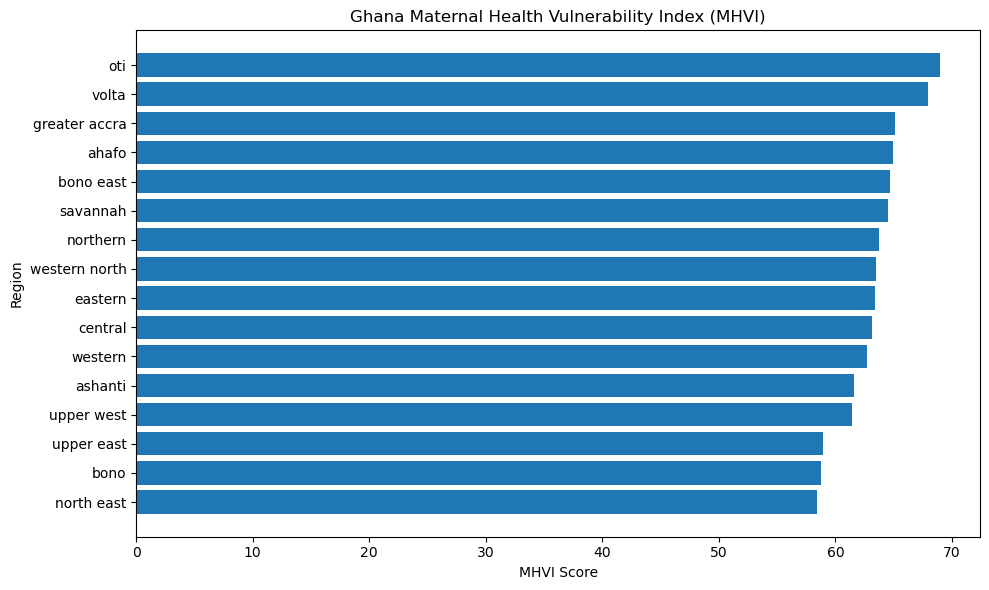

In [68]:
import matplotlib.pyplot as plt

ghana_mhvi_sorted = ghana_mhvi.sort_values("MHVI")

plt.figure(figsize=(10,6))
plt.barh(ghana_mhvi_sorted["NAME_1"], ghana_mhvi_sorted["MHVI"])

plt.title("Ghana Maternal Health Vulnerability Index (MHVI)")
plt.xlabel("MHVI Score")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [69]:
ghana_mhvi.head()

,NAME_1,MHVI
0,western,62.700000
1,western north,63.450000
2,central,63.175000
3,greater accra,65.100000
4,volta,67.933333


In [70]:
ghana_mhvi_sorted = ghana_mhvi.sort_values("MHVI", ascending=False)
ghana_mhvi_sorted["Rank"] = range(1, len(ghana_mhvi_sorted) + 1)
ghana_mhvi_sorted

,NAME_1,MHVI,Rank
5,oti,68.958333,1
4,volta,67.933333,2
3,greater accra,65.100000,3
8,ahafo,64.975000,4
10,bono east,64.683333,5
12,savannah,64.508333,6
11,northern,63.775000,7
1,western north,63.450000,8
6,eastern,63.408333,9
2,central,63.175000,10


In [71]:
ghana_mhvi_sorted.iloc[0]

NAME_1          oti
MHVI      68.958333
Rank              1
Name: 5, dtype: object

In [72]:
indicator_cols = final_results.columns.drop(["Region", "MHVI", "Rank"])
indicator_cols

Index(['ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Height_below_145cm', 'Any_anaemia', 'No_education', 'Improved_water',
       'Improved_sanitation', 'Lowest_wealth_quintile'],
      dtype='object')

In [73]:
risk_profile = final_results[["Region"] + list(indicator_cols)].copy()
risk_profile

,Region,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
5,oti,95.8,71.5,98.8,97.2,97.7,98.3,1.0,47.0,36.4,96.8,30.0,57.0
4,volta,95.0,71.7,98.9,98.6,92.8,91.7,0.0,46.3,43.4,97.9,26.9,52.0
3,greater accra,90.7,66.1,96.8,99.4,91.3,92.8,0.3,37.5,16.1,96.8,84.7,8.7
8,ahafo,94.2,71.2,99.4,99.4,90.5,93.8,1.0,43.0,17.2,88.4,67.7,13.9
10,bono east,91.3,65.1,98.6,98.3,93.1,93.9,0.4,35.6,23.9,83.3,54.2,38.5
12,savannah,86.8,66.7,99.4,99.2,84.2,85.2,0.5,40.3,32.7,86.4,57.2,35.5
11,northern,91.8,66.5,98.2,98.7,89.7,91.2,0.5,30.1,21.1,92.2,71.3,14.0
1,western north,87.3,60.7,94.3,94.2,91.3,92.3,0.2,38.8,10.0,98.5,91.4,2.4
6,eastern,91.6,68.6,95.0,96.2,84.1,85.4,0.5,45.9,17.7,94.3,72.6,9.0
2,central,91.0,64.8,97.9,99.6,89.2,90.1,0.7,37.5,15.7,88.7,74.7,8.2


In [74]:
national_avg = final_results[indicator_cols].mean()

In [75]:
deviation = final_results[indicator_cols] - national_avg
deviation.insert(0, "Region", final_results["Region"])
deviation

,Region,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Height_below_145cm,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile
5,oti,8.14375,6.71875,2.04375,0.15,12.46875,11.7375,0.49375,5.05625,6.91875,11.8875,-25.0875,28.14375
4,volta,7.34375,6.91875,2.14375,1.55,7.56875,5.1375,-0.50625,4.35625,13.91875,12.9875,-28.1875,23.14375
3,greater accra,3.04375,1.31875,0.04375,2.35,6.06875,6.2375,-0.20625,-4.44375,-13.38125,11.8875,29.6125,-20.15625
8,ahafo,6.54375,6.41875,2.64375,2.35,5.26875,7.2375,0.49375,1.05625,-12.28125,3.4875,12.6125,-14.95625
10,bono east,3.64375,0.31875,1.84375,1.25,7.86875,7.3375,-0.10625,-6.34375,-5.58125,-1.6125,-0.8875,9.64375
12,savannah,-0.85625,1.91875,2.64375,2.15,-1.03125,-1.3625,-0.00625,-1.64375,3.21875,1.4875,2.1125,6.64375
11,northern,4.14375,1.71875,1.44375,1.65,4.46875,4.6375,-0.00625,-11.84375,-8.38125,7.2875,16.2125,-14.85625
1,western north,-0.35625,-4.08125,-2.45625,-2.85,6.06875,5.7375,-0.30625,-3.14375,-19.48125,13.5875,36.3125,-26.45625
6,eastern,3.94375,3.81875,-1.75625,-0.85,-1.13125,-1.1625,-0.00625,3.95625,-11.78125,9.3875,17.5125,-19.85625
2,central,3.34375,0.01875,1.14375,2.55,3.96875,3.5375,0.19375,-4.44375,-13.78125,3.7875,19.6125,-20.65625


In [76]:
def top_drivers(row, n=3):
    values = row[indicator_cols]
    return values.sort_values(ascending=False).head(n)

final_results.apply(top_drivers, axis=1)

,ANC_4plus_visits,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Improved_water,Skilled_provider_delivery
5,NaN,98.8,NaN,97.7,NaN,98.3
4,NaN,98.9,98.6,NaN,97.9,NaN
3,NaN,96.8,99.4,NaN,96.8,NaN
8,94.2,99.4,99.4,NaN,NaN,NaN
10,NaN,98.6,98.3,NaN,NaN,93.9
12,86.8,99.4,99.2,NaN,NaN,NaN
11,NaN,98.2,98.7,NaN,92.2,NaN
1,NaN,94.3,94.2,NaN,98.5,NaN
6,NaN,95.0,96.2,NaN,94.3,NaN
2,91.0,97.9,99.6,NaN,NaN,NaN


In [77]:
def explain_region(row):
    top = row[indicator_cols].sort_values(ascending=False).head(3)
    explanation = f"{row['Region']} is driven by: " + \
        ", ".join([f"{i} ({v:.2f})" for i, v in top.items()])
    return explanation

final_results["Explanation"] = final_results.apply(explain_region, axis=1)

final_results[["Region", "MHVI", "Explanation"]]

,Region,MHVI,Explanation
5,oti,68.958333,"oti is driven by: ANC_BP_measured (98.80), Ski..."
4,volta,67.933333,"volta is driven by: ANC_BP_measured (98.90), A..."
3,greater accra,65.100000,greater accra is driven by: ANC_urine_taken (9...
8,ahafo,64.975000,"ahafo is driven by: ANC_BP_measured (99.40), A..."
10,bono east,64.683333,bono east is driven by: ANC_BP_measured (98.60...
12,savannah,64.508333,savannah is driven by: ANC_BP_measured (99.40)...
11,northern,63.775000,northern is driven by: ANC_urine_taken (98.70)...
1,western north,63.450000,western north is driven by: Improved_water (98...
6,eastern,63.408333,"eastern is driven by: ANC_urine_taken (96.20),..."
2,central,63.175000,"central is driven by: ANC_urine_taken (99.60),..."


In [78]:
final_results[["Region", "MHVI", "Explanation"]].head()

,Region,MHVI,Explanation
5,oti,68.958333,"oti is driven by: ANC_BP_measured (98.80), Ski..."
4,volta,67.933333,"volta is driven by: ANC_BP_measured (98.90), A..."
3,greater accra,65.100000,greater accra is driven by: ANC_urine_taken (9...
8,ahafo,64.975000,"ahafo is driven by: ANC_BP_measured (99.40), A..."
10,bono east,64.683333,bono east is driven by: ANC_BP_measured (98.60...


In [79]:
final_results.columns

Index(['Region', 'ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Height_below_145cm', 'Any_anaemia', 'No_education', 'Improved_water',
       'Improved_sanitation', 'Lowest_wealth_quintile', 'MHVI', 'Rank',
       'Explanation'],
      dtype='object')

In [80]:
final_results[["Region", "MHVI"]].head()

,Region,MHVI
5,oti,68.958333
4,volta,67.933333
3,greater accra,65.100000
8,ahafo,64.975000
10,bono east,64.683333


In [81]:
final_results["MHVI"].describe()

count    16.000000
mean     63.235417
std       2.985186
min      58.400000
25%      61.533333
50%      63.429167
75%      64.756250
max      68.958333
Name: MHVI, dtype: float64

In [82]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', '_i2', 'df', '_2', '_i3', '_i4', '_4', '_i5', '_5', '_i6', 'df_sorted', '_6', '_i7', '_7', '_i8', 'profile_cols', '_8', '_i9', 'regions', 'data', '_9', '_i10', 'corr_matrix', '_10', '_i11', '_i12', 'threshold', 'high_corr_pairs', 'i', 'j', 'corr_value', '_12', '_i13', '_i14', '_14', '_i15', 'mhvi_data', '_15', '_i16', 'mhvi_aligned', '_16', '_i17', 'protective_vars', 'col', '_17', '_i18', 'check_col', 'comparison', '_18', '_i19', 'mhvi_normalized', '_19', '_i20', '_20', '_i21', '_21', '_i22', '_22', '_i23', 'mhvi_results', 'mhvi_ranked', '_23', '_i24', '_24', '_i25', 'most_vulnerable', 'least_vulnerable', '_i26', '_i27', 'validation_cols', 'validation_data', 'correlations', '_i28', '_i29', '_29', '_i30', 'final_results', '_3

In [83]:
[var for var in globals().keys() if "norm" in var.lower()]

['mhvi_normalized']

In [84]:
[var for var in globals().keys() if "mhvi" in var.lower()]

['mhvi_data',
 'mhvi_aligned',
 'mhvi_normalized',
 'mhvi_results',
 'mhvi_ranked',
 'classify_mhvi',
 'mhvi_map_data',
 'ghana_mhvi',
 'ghana_mhvi_sorted']

In [85]:
mhvi_normalized.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI
0,0.319635,0.325581,0.405405,0.1125,0.491909,0.496528,0.658986,0.209850,0.170918,0.279137,0.108590,0.325367
1,0.388128,0.511628,0.689189,0.6750,0.207120,0.208333,0.400922,0.000000,0.000000,0.000000,0.000000,0.280029
2,0.219178,0.320930,0.202703,0.0000,0.275081,0.284722,0.341014,0.122056,0.250000,0.240288,0.094003,0.213634
3,0.232877,0.260465,0.351351,0.0250,0.207120,0.190972,0.341014,0.130621,0.043367,0.096403,0.102107,0.180118
4,0.036530,0.000000,0.067568,0.1250,0.158576,0.229167,0.746544,0.715203,0.015306,0.928058,0.803890,0.347804


In [86]:
mhvi_normalized.describe()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.371861,0.321802,0.357264,0.318750,0.403519,0.407552,0.545795,0.417157,0.346620,0.522482,0.428788,0.403781
std,0.297769,0.258705,0.306371,0.335690,0.294404,0.300267,0.261102,0.322120,0.331630,0.324498,0.336221,0.236012
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.180118
25%,0.189498,0.210465,0.101351,0.096875,0.207120,0.203993,0.341014,0.162206,0.091199,0.276978,0.108185,0.263430
50%,0.276256,0.283721,0.304054,0.162500,0.296117,0.296875,0.599078,0.267666,0.253827,0.513669,0.370340,0.325065
75%,0.495434,0.388372,0.608108,0.487500,0.489482,0.501736,0.732719,0.602784,0.459821,0.883813,0.701783,0.426922
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.861460


In [87]:
mhvi_normalized.columns

Index(['ANC_4plus_visits', 'ANC_first_before_4mo', 'ANC_BP_measured',
       'ANC_urine_taken', 'Facility_delivery', 'Skilled_provider_delivery',
       'Any_anaemia', 'No_education', 'Improved_water', 'Improved_sanitation',
       'Lowest_wealth_quintile', 'MHVI'],
      dtype='object')

In [88]:
mhvi_normalized.head()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI
0,0.319635,0.325581,0.405405,0.1125,0.491909,0.496528,0.658986,0.209850,0.170918,0.279137,0.108590,0.325367
1,0.388128,0.511628,0.689189,0.6750,0.207120,0.208333,0.400922,0.000000,0.000000,0.000000,0.000000,0.280029
2,0.219178,0.320930,0.202703,0.0000,0.275081,0.284722,0.341014,0.122056,0.250000,0.240288,0.094003,0.213634
3,0.232877,0.260465,0.351351,0.0250,0.207120,0.190972,0.341014,0.130621,0.043367,0.096403,0.102107,0.180118
4,0.036530,0.000000,0.067568,0.1250,0.158576,0.229167,0.746544,0.715203,0.015306,0.928058,0.803890,0.347804


In [89]:
mhvi_normalized.describe()

,ANC_4plus_visits,ANC_first_before_4mo,ANC_BP_measured,ANC_urine_taken,Facility_delivery,Skilled_provider_delivery,Any_anaemia,No_education,Improved_water,Improved_sanitation,Lowest_wealth_quintile,MHVI
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.371861,0.321802,0.357264,0.318750,0.403519,0.407552,0.545795,0.417157,0.346620,0.522482,0.428788,0.403781
std,0.297769,0.258705,0.306371,0.335690,0.294404,0.300267,0.261102,0.322120,0.331630,0.324498,0.336221,0.236012
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.180118
25%,0.189498,0.210465,0.101351,0.096875,0.207120,0.203993,0.341014,0.162206,0.091199,0.276978,0.108185,0.263430
50%,0.276256,0.283721,0.304054,0.162500,0.296117,0.296875,0.599078,0.267666,0.253827,0.513669,0.370340,0.325065
75%,0.495434,0.388372,0.608108,0.487500,0.489482,0.501736,0.732719,0.602784,0.459821,0.883813,0.701783,0.426922
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.861460


In [90]:
len(final_results), len(mhvi_normalized)

(16, 16)

In [91]:
# Attaching the scientifically correct MHVI recovered from the normalized dataset

final_results["MHVI_Correct"] = mhvi_normalized["MHVI"].values

# Quick check
final_results[["Region", "MHVI_Correct"]].head()

,Region,MHVI_Correct
5,oti,0.325367
4,volta,0.280029
3,greater accra,0.213634
8,ahafo,0.180118
10,bono east,0.347804


In [92]:
# Create rankings using the correct MHVI

final_results["Rank_Correct"] = (
    final_results["MHVI_Correct"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

# View ranking table
final_results[["Region", "MHVI_Correct", "Rank_Correct"]]\
    .sort_values("Rank_Correct")\
    .head(16)

,Region,MHVI_Correct,Rank_Correct
14,upper east,0.861460,1
9,bono,0.839502,2
13,north east,0.772985,3
2,central,0.649881,4
15,upper west,0.352602,5
10,bono east,0.347804,6
11,northern,0.329201,7
5,oti,0.325367,8
1,western north,0.324763,9
12,savannah,0.322386,10


In [93]:
# Create vulnerability categories using tertiles

q1 = final_results["MHVI_Correct"].quantile(0.33)
q2 = final_results["MHVI_Correct"].quantile(0.67)

def classify_vulnerability(score):
    if score >= q2:
        return "High Vulnerability"
    elif score >= q1:
        return "Medium Vulnerability"
    else:
        return "Low Vulnerability"

final_results["Vulnerability_Category"] = (
    final_results["MHVI_Correct"]
    .apply(classify_vulnerability)
)

# Check distribution
final_results["Vulnerability_Category"].value_counts()

Vulnerability_Category
Medium Vulnerability    6
Low Vulnerability       5
High Vulnerability      5
Name: count, dtype: int64

In [94]:
# Indicators used in MHVI

indicator_cols = [
    'ANC_4plus_visits',
    'ANC_first_before_4mo',
    'ANC_BP_measured',
    'ANC_urine_taken',
    'Facility_delivery',
    'Skilled_provider_delivery',
    'Any_anaemia',
    'No_education',
    'Improved_water',
    'Improved_sanitation',
    'Lowest_wealth_quintile'
]

# Create explanations

explanations = []

for i in range(len(mhvi_normalized)):

    top3 = (
        mhvi_normalized.loc[i, indicator_cols]
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )

    explanations.append(", ".join(top3))

final_results["Top_Drivers"] = explanations

# View results

final_results[
    ["Region",
     "MHVI_Correct",
     "Vulnerability_Category",
     "Top_Drivers"]
].sort_values("MHVI_Correct", ascending=False)

,Region,MHVI_Correct,Vulnerability_Category,Top_Drivers
14,upper east,0.861460,High Vulnerability,"ANC_first_before_4mo, ANC_BP_measured, ANC_uri..."
9,bono,0.839502,High Vulnerability,"ANC_4plus_visits, No_education, Improved_sanit..."
13,north east,0.772985,High Vulnerability,"ANC_urine_taken, Improved_water, Improved_sani..."
2,central,0.649881,High Vulnerability,"Facility_delivery, Skilled_provider_delivery, ..."
15,upper west,0.352602,High Vulnerability,"Lowest_wealth_quintile, Improved_sanitation, N..."
10,bono east,0.347804,Medium Vulnerability,"Improved_sanitation, Lowest_wealth_quintile, A..."
11,northern,0.329201,Medium Vulnerability,"Any_anaemia, ANC_BP_measured, Skilled_provider..."
5,oti,0.325367,Medium Vulnerability,"Any_anaemia, Skilled_provider_delivery, Facili..."
1,western north,0.324763,Medium Vulnerability,"Improved_sanitation, ANC_4plus_visits, Improve..."
12,savannah,0.322386,Medium Vulnerability,"Lowest_wealth_quintile, Improved_sanitation, A..."


In [95]:
indicator_importance = (
    mhvi_normalized[indicator_cols]
    .mean()
    .sort_values(ascending=False)
)

indicator_importance

Any_anaemia                  0.545795
Improved_sanitation          0.522482
Lowest_wealth_quintile       0.428788
No_education                 0.417157
Skilled_provider_delivery    0.407552
Facility_delivery            0.403519
ANC_4plus_visits             0.371861
ANC_BP_measured              0.357264
Improved_water               0.346620
ANC_first_before_4mo         0.321802
ANC_urine_taken              0.318750
dtype: float64

In [96]:
indicator_cols = [
    'ANC_4plus_visits',
    'ANC_first_before_4mo',
    'ANC_BP_measured',
    'ANC_urine_taken',
    'Facility_delivery',
    'Skilled_provider_delivery',
    'Any_anaemia',
    'No_education',
    'Improved_water',
    'Improved_sanitation',
    'Lowest_wealth_quintile'
]

national_means = mhvi_normalized[indicator_cols].mean()
national_means

ANC_4plus_visits             0.371861
ANC_first_before_4mo         0.321802
ANC_BP_measured              0.357264
ANC_urine_taken              0.318750
Facility_delivery            0.403519
Skilled_provider_delivery    0.407552
Any_anaemia                  0.545795
No_education                 0.417157
Improved_water               0.346620
Improved_sanitation          0.522482
Lowest_wealth_quintile       0.428788
dtype: float64

In [97]:
def get_drivers(row):
    diffs = row[indicator_cols] - national_means
    top3 = diffs.sort_values(ascending=False).head(3).index.tolist()
    return ", ".join(top3)

final_results["Top_Drivers_Improved"] = mhvi_normalized.apply(get_drivers, axis=1)

final_results[
    ["Region", "MHVI_Correct", "Vulnerability_Category", "Top_Drivers_Improved"]
].sort_values("MHVI_Correct", ascending=False)

,Region,MHVI_Correct,Vulnerability_Category,Top_Drivers_Improved
14,upper east,0.861460,High Vulnerability,"ANC_4plus_visits, Improved_water, No_education"
9,bono,0.839502,High Vulnerability,"Facility_delivery, Skilled_provider_delivery, ..."
13,north east,0.772985,High Vulnerability,"ANC_first_before_4mo, ANC_urine_taken, ANC_BP_..."
2,central,0.649881,High Vulnerability,"ANC_first_before_4mo, Improved_water, Skilled_..."
15,upper west,0.352602,High Vulnerability,"ANC_urine_taken, Improved_water, Lowest_wealth..."
10,bono east,0.347804,Medium Vulnerability,"Lowest_wealth_quintile, Improved_water, Improv..."
11,northern,0.329201,Medium Vulnerability,"ANC_first_before_4mo, Facility_delivery, Skill..."
5,oti,0.325367,Medium Vulnerability,"Lowest_wealth_quintile, Improved_sanitation, A..."
1,western north,0.324763,Medium Vulnerability,"ANC_urine_taken, ANC_BP_measured, ANC_first_be..."
12,savannah,0.322386,Medium Vulnerability,"Lowest_wealth_quintile, No_education, Skilled_..."


In [98]:
import os
os.makedirs("../data/processed", exist_ok=True)
final_results.to_csv("../data/processed/final_results_mhvi.csv", index=False)
print(" Done")

 Done


In [99]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [100]:
import shap
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import os

features = [
    "ANC_4plus_visits", "ANC_first_before_4mo", "ANC_BP_measured",
    "ANC_urine_taken", "Facility_delivery", "Skilled_provider_delivery",
    "Any_anaemia", "No_education", "Lowest_wealth_quintile",
    "Improved_water", "Improved_sanitation"
]

X = final_results[features]
y = final_results["MHVI_Correct"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Plot 1 — Summary plot (all regions)
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("../maps/shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()
print("Summary plot saved")

# Plot 2 — Upper East waterfall (highest risk region)
region_index = final_results[
    final_results["Region"] == "upper east"
].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[region_index],
        base_values=explainer.expected_value,
        data=X.iloc[region_index],
        feature_names=features
    ), show=False
)
plt.tight_layout()
plt.savefig("../maps/shap_upper_east.png", dpi=150, bbox_inches="tight")
plt.close()
print("Upper East waterfall saved")

Summary plot saved
Upper East waterfall saved


In [101]:
import os
files = os.listdir("../maps/")
print(files)

['shap_summary.png', 'shap_upper_east.png']
